# Simulations

Here we illustrate how to run simulations, using the ``atomsmltr.simulation.simulator`` subpackage

We only provide minimal examples here. Please have a look at the examples in the **atomic physic** section for more examples.

## Minimal example of a simulation

Here is a very simple example, where we only include a pair of lasers along z (modelled as plane waves), and launch one ytterbium atom with an initial speed of 100 m/s along z.

We use the simulator based on Scipy's ``solve_IVP`` method, namely ``ScipyIVP_3D``. When we only need to perform one simulation, the easiest is to use the ``integrate()`` method.

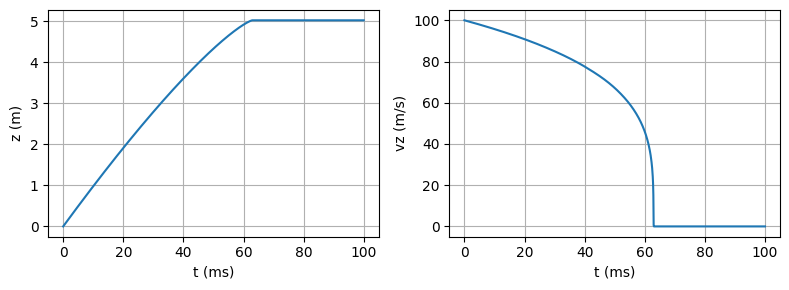

In [12]:
from atomsmltr.environment import PlaneWaveLaserBeam
from atomsmltr.atoms import Ytterbium
from atomsmltr.simulation import Configuration, ScipyIVP_3D
import numpy as np
import matplotlib.pyplot as plt

# - setup atom
atom = Ytterbium()
main = atom.trans["main"] # get transition, to help setting up lasers

# - setup laser
laser_1 = PlaneWaveLaserBeam()
laser_1.direction = (0, 0, 1)
laser_1.set_power_from_I(main.Isat) # set power to reach Isat
laser_1.tag = "las1"

laser_2 = laser_1.copy() # create a copy
laser_2.direction = (0, 0, -1)  # propagating in opposite direction
laser_2.tag = "las2"

# - config
config = Configuration()
config.atom = atom
config += laser_1, laser_2
config.add_atomlight_coupling("las1", "main", -0.5 * main.Gamma)
config.add_atomlight_coupling("las2", "main", -0.5 * main.Gamma)

# - simulation
sim = ScipyIVP_3D(config=config)
t = np.linspace(0, 0.1, 1000)  # timesteps for integration
u0 = (0, 0, 0, 0, 0, 100)  # atom starts with vz=100m/s
res = sim.integrate(u0, t)

# plot
fix, axes = plt.subplots(1, 2, figsize=(8, 3), tight_layout=True)
axes[0].plot(res.t * 1e3, res.y[2])
axes[0].set_ylabel("z (m)")
axes[1].plot(res.t * 1e3, res.y[5])
axes[1].set_ylabel("vz (m/s)")
for ax in axes:
    ax.set_xlabel("t (ms)")
    ax.grid()

## Parallel computation

The simulator makes it easy to perform several simulations in parallel. For that, one has to provide a list of initial conditions ``u0_list`` and use the ``run()`` method :

In [42]:
# - simulation
# using the same configuration as before
sim = ScipyIVP_3D(config=config)
t = np.linspace(0, 0.1, 1000)  # timesteps for integration

# prepare initial conditions
vz_list = np.linspace(1, 130, 100)
u0_list = [(0,0,0,0,0,vz) for vz in vz_list]

# run
sim.u0_list = u0_list
res_coll = sim.run(t, npools=5, verbose=True)

100%|██████████| 100/100 [00:01<00:00, 97.59it/s]


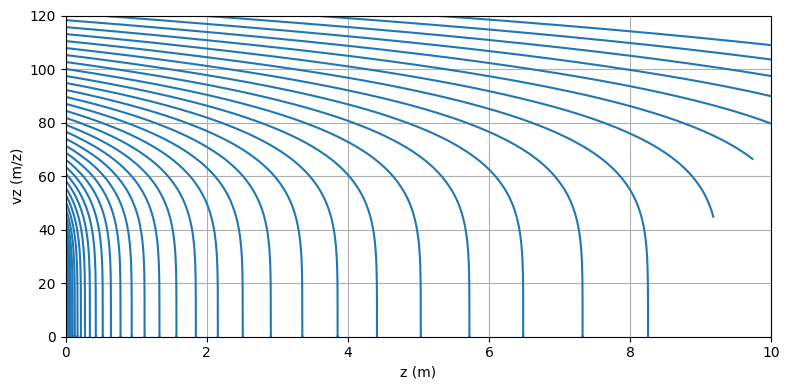

In [43]:
# plot
plt.figure(figsize=(8, 4), tight_layout=True)
for res in res_coll[::2]:
    plt.plot(res.y[2], res.y[5], color="C0")
plt.xlabel("z (m)")
plt.ylabel("vz (m/z)")
plt.xlim(0, 10)
plt.ylim(0, 120)
plt.grid()
plt.show()